In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(42)

n, a, b, sigma = 25, 1.0, 5.0, 0.25
max_depth = 3
B = 3
colors = ["tab:red", "tab:green", "tab:blue"]

In [2]:
x = rng.uniform(0, 1, n).reshape(-1, 1)
y = a + b * x.ravel() + rng.normal(0, sigma, n)

xx = np.linspace(0, 1, 400).reshape(-1, 1)
y_true = a + b * xx.ravel()

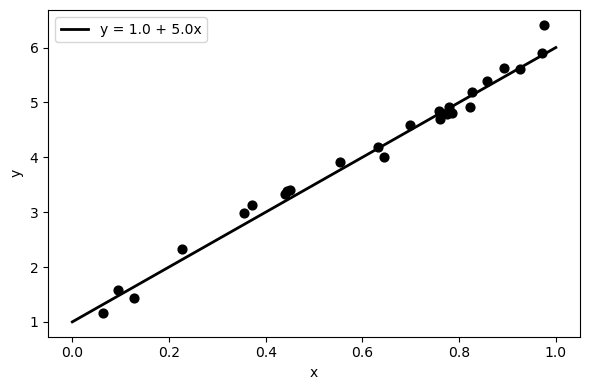

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, color="black", s=40, zorder=3)
ax.plot(xx, y_true, color="black", lw=2, label=f"y = {a} + {b}x")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
boots, preds = [], []
for k in range(B):
    idx = rng.integers(0, n, size=n)
    tree = DecisionTreeRegressor(max_depth=max_depth, random_state=0).fit(x[idx], y[idx])
    boots.append(idx)
    preds.append(tree.predict(xx))

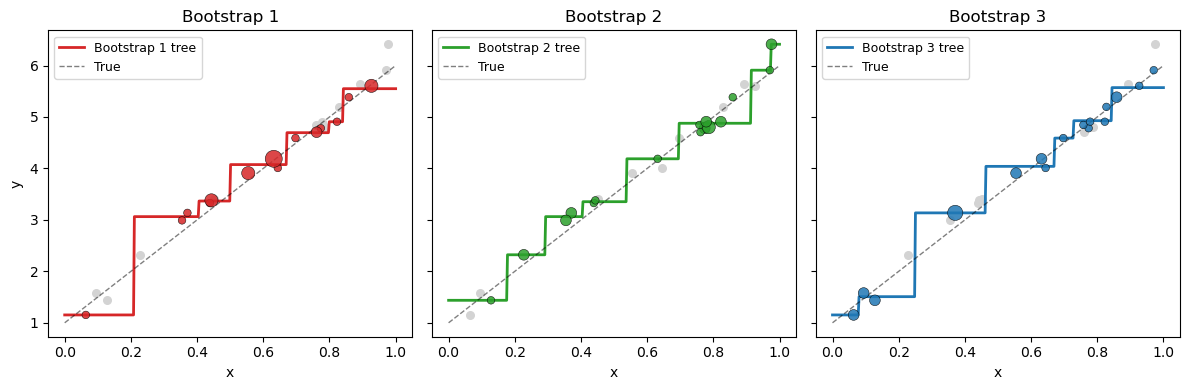

In [5]:
fig, axes = plt.subplots(1, B, figsize=(4 * B, 4), sharey=True)
for k, ax in enumerate(axes):
    idx = boots[k]
    unique_idx, counts = np.unique(idx, return_counts=True)
    in_boot = np.zeros(n, dtype=bool)
    in_boot[unique_idx] = True
    # out-of-bag points: faint gray
    ax.scatter(x[~in_boot], y[~in_boot], color="lightgray", s=30, zorder=1)
    # in-bag points: colored, size proportional to draw count
    ax.scatter(
        x[unique_idx].ravel(), y[unique_idx],
        color=colors[k], s=30 * counts, alpha=0.85,
        edgecolor="black", linewidth=0.4, zorder=3,
    )
    # tree fit on this bootstrap sample
    ax.plot(xx, preds[k], color=colors[k], lw=2, zorder=2,
            label=f"Bootstrap {k + 1} tree")
    # true function for reference
    ax.plot(xx, y_true, color="black", lw=1, ls="--", alpha=0.5, zorder=2,
            label="True")
    ax.set_xlabel("x")
    if k == 0:
        ax.set_ylabel("y")
    ax.set_title(f"Bootstrap {k + 1}")
    ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

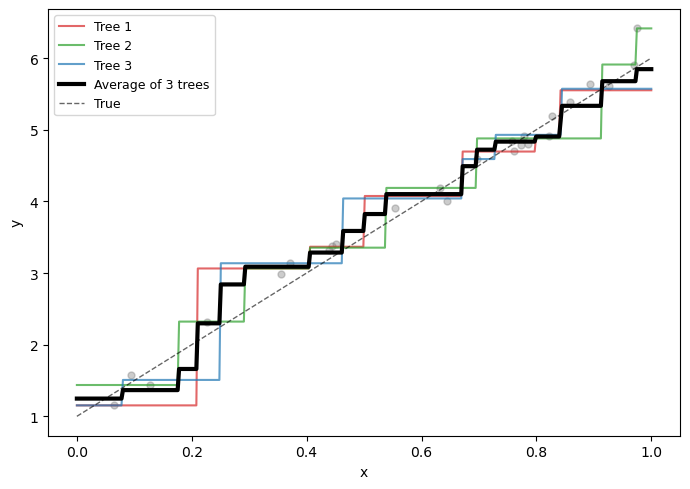

In [6]:
avg = np.mean(preds, axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, color="gray", alpha=0.4, s=25, zorder=1)
for k in range(B):
    ax.plot(xx, preds[k], color=colors[k], lw=1.5, alpha=0.7,
            label=f"Tree {k + 1}", zorder=2)
ax.plot(xx, avg, color="black", lw=3, label="Average of 3 trees", zorder=4)
ax.plot(xx, y_true, color="black", lw=1, ls="--", alpha=0.6,
        label="True", zorder=3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()